In [59]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [60]:
import urllib.request
 
URL = "https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt"
 
with urllib.request.urlopen(URL) as response:
    text = response.read().decode("utf-8")
 
words = [line.strip() for line in text.splitlines() if line.strip()]

In [61]:
words

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [62]:
NUM_LETTERS = 26
NUM_SPECIAL = 1
NUM_TOKENS = NUM_LETTERS + NUM_SPECIAL

alphabet = list(bytes([list('a'.encode("utf-8"))[0] + i for i in range(NUM_LETTERS)]).decode('utf-8'))

stoi = {
    ".": 0
}
itos = {
    0: "."
}
for i, s in enumerate(alphabet):
    stoi[s] = i + 1
    itos[i + 1] = s

itos

{0: '.',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

In [63]:
import random
CONTEXT_SIZE = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        w = w.lower()
        context = [0] * CONTEXT_SIZE
        for s in w + ".":
            i = stoi[s]
            X.append(context)
            Y.append(i)
            context = context[1:] + [i]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)

    return X, Y

random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

# split the dataset into training, validation (dev) and test sets
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [64]:
# if the NN weights of the softmax were set uniform at random, we would expect the NLL to be 1/27 (each character is equally probable)
# therefore, we want the first loss to be roughly -log(1/27)

-torch.tensor(1/27.0).log()

tensor(3.2958)

In [65]:
EMBEDDING_SIZE = 10
NUM_HIDDED_NEURONS = 200

# if we randomly initialize the parameters, the NN is going to be confidently wrong and therefore the first loss will be really high
# this is undersired, as the several initial iterations will be wasted in getting the neural network less confidently wrong
# to avoid this, we set the bias to 0 and ensure the weights are small so that they do not make the loss unnecessarily high

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((NUM_TOKENS, EMBEDDING_SIZE), generator=g)
W1 = torch.randn((CONTEXT_SIZE * EMBEDDING_SIZE), NUM_HIDDED_NEURONS, generator=g)
b1 = torch.randn(NUM_HIDDED_NEURONS, generator=g)
W2 = torch.randn(NUM_HIDDED_NEURONS, NUM_TOKENS, generator=g) * 0.01
b2 = torch.randn(NUM_TOKENS, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(f"number of parameters: {sum([p.nelement() for p in parameters])}")

for p in parameters:
    p.requires_grad = True

number of parameters: 11897


In [66]:
TRAINING_STEPS = 200_000
BATCH_SIZE = 32

lossi = []
for i in range(TRAINING_STEPS):
    idx = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)

    # forward
    emb = C[Xtr[idx]] # sample a random subset (of size BATCH_SIZE) of the input
    h = torch.tanh(emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[idx])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{TRAINING_STEPS:7d}: {loss.item():.4f}")
        lossi.append(loss.item())

# the inital loss is roughly the expected log(1/27), ensuring the NN is not unnecessarily biased and wrong

      0/ 200000: 3.3221
  10000/ 200000: 2.1900
  20000/ 200000: 2.4196
  30000/ 200000: 2.6067
  40000/ 200000: 2.0601
  50000/ 200000: 2.4988
  60000/ 200000: 2.3902
  70000/ 200000: 2.1344
  80000/ 200000: 2.3369
  90000/ 200000: 2.1299
 100000/ 200000: 1.8329
 110000/ 200000: 2.2053
 120000/ 200000: 1.8540
 130000/ 200000: 2.4566
 140000/ 200000: 2.1879
 150000/ 200000: 2.1118
 160000/ 200000: 1.8956
 170000/ 200000: 1.8644
 180000/ 200000: 2.0326
 190000/ 200000: 1.8417


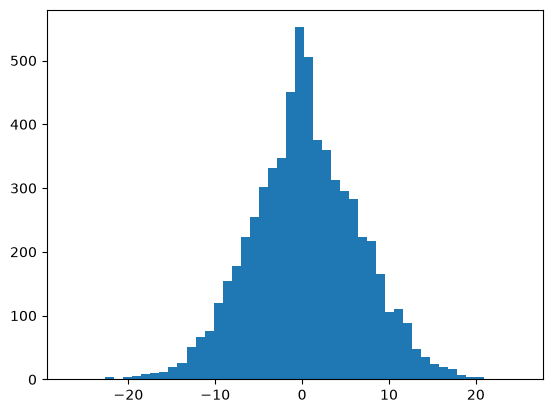

In [67]:
# the distribution of the preactivation is really wide
# and this causes the values far from the norm to be squash on the -1 or 1 side of the activations
hpreact = emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE) @ W1 + b1
plt.hist(hpreact.view(-1).tolist(), 50);

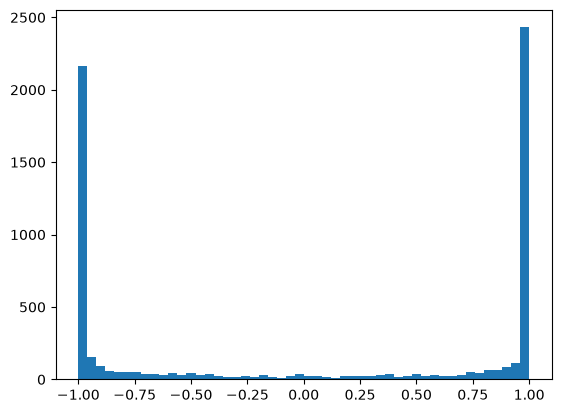

In [68]:
# !!! the values of most of the activations are either -1 or 1 !!!
# this is a big problem because the derivative on tanh when tanh is either -1 or 1 is 0
# therefore, all the gradients of these parameters are not actually being updated during backpropagation
plt.hist(h.view(-1).tolist(), 50);

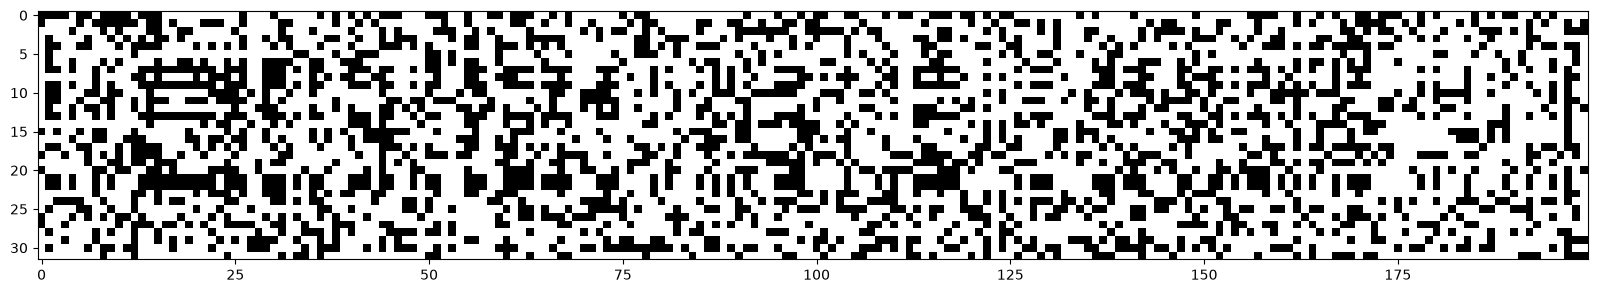

In [69]:
# if a neuron happens to have the activations in either -1 or 1 for all the samples in the minibatch (32 rows)
# the neuron would be a dead neuron, i.e. it cannot learn (would result in a column full of white squares)
# luckily in this case, there is none and so each neuron is in the active part of the tanh for some samples of the minibatch and so it will learn
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [70]:
# to prevent the activitation from saturating, we need to ensure that the values of the preactivations are "small"
# to ensure this we also scale the values of W1 and b1 so that the preactivation is closer to 0

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((NUM_TOKENS, EMBEDDING_SIZE), generator=g)
W1 = torch.randn((CONTEXT_SIZE * EMBEDDING_SIZE), NUM_HIDDED_NEURONS, generator=g) * 0.2
b1 = torch.randn(NUM_HIDDED_NEURONS, generator=g) * 0.01
W2 = torch.randn(NUM_HIDDED_NEURONS, NUM_TOKENS, generator=g) * 0.01
b2 = torch.randn(NUM_TOKENS, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(f"number of parameters: {sum([p.nelement() for p in parameters])}")

for p in parameters:
    p.requires_grad = True

number of parameters: 11897


In [71]:
TRAINING_STEPS = 1
BATCH_SIZE = 32

lossi = []
for i in range(TRAINING_STEPS):
    idx = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)

    # forward
    emb = C[Xtr[idx]] # sample a random subset (of size BATCH_SIZE) of the input
    h = torch.tanh(emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[idx])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{TRAINING_STEPS:7d}: {loss.item():.4f}")
        lossi.append(loss.item())

      0/      1: 3.3135


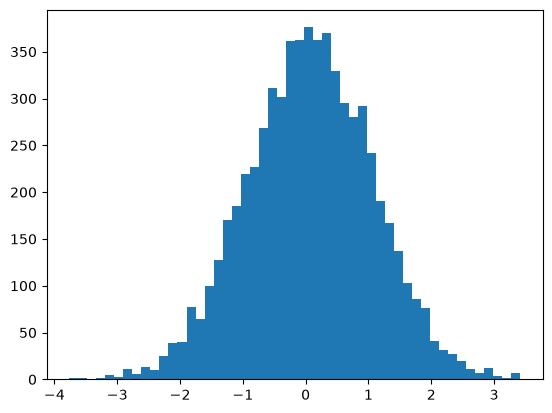

In [72]:
# the distribution of values of the preactivations is now much more narrow
hpreact = emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE) @ W1 + b1
plt.hist(hpreact.view(-1).tolist(), 50);

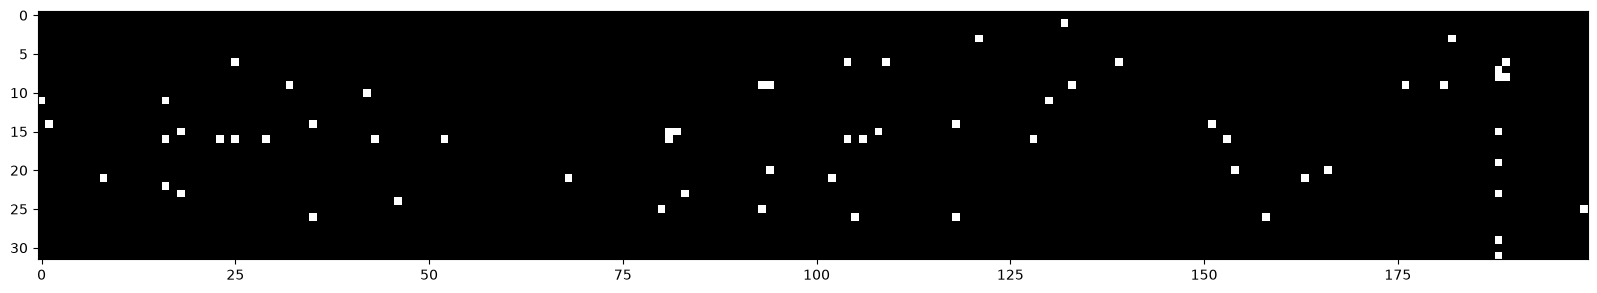

In [73]:
# and finally, all the neurons are being updated for each sample in the batch
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

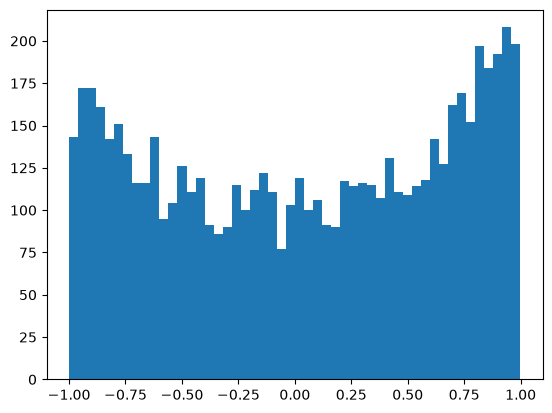

In [74]:
# and so most of the activations are in the active part of the tanh
plt.hist(h.view(-1).tolist(), 50);

tensor(-0.0075) tensor(1.0016)
tensor(0.0014) tensor(3.0768)


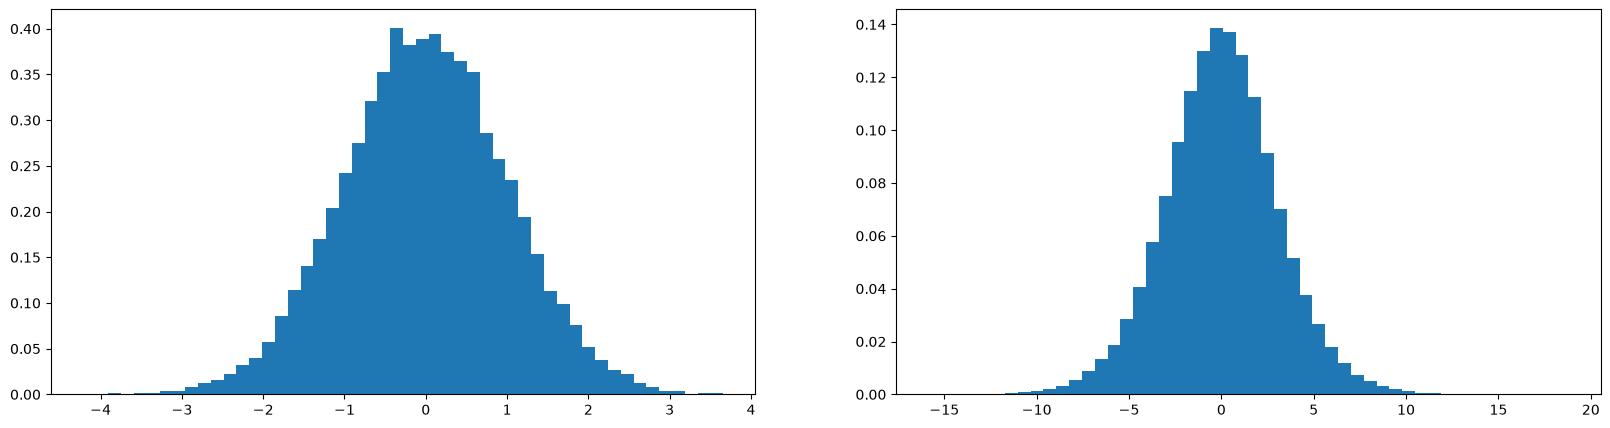

In [ ]:
# how do we set the scalars for the various parameters?
# the inputs and parameters are initialized to a uniform gaussian (norm 0 and std dev 1)
# however, as we multiply the inputs and parameters together the std dev increases

x = torch.randn(1000, 10)
w = torch.randn(10, 200)

y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);



In [ ]:
# we need to set the scalar of w so that y = x @ w has std dev 1
# after deriving how the std dev changes after the matrix multiplication, it turns out that we need to divide by the square root of the fan in of w

# w fan in = 10
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5

y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

tensor(0.0142) tensor(0.9962)
tensor(0.0013) tensor(1.0094)


In [ ]:
# pytorch provides this initialization out of the box for the activation layer
# the tanh nonlinearity adds a gain of 5/3 to the scalar
torch.nn.init.kaiming_normal_(torch.empty(10, 200), mode='fan_in', nonlinearity='tanh')

tensor(0.0050) tensor(1.0021)
tensor(-0.0003) tensor(0.3815)


In [102]:
# the correct initialization is therefore:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((NUM_TOKENS, EMBEDDING_SIZE), generator=g)
W1 = torch.randn((CONTEXT_SIZE * EMBEDDING_SIZE), NUM_HIDDED_NEURONS, generator=g) * (5/3) / (CONTEXT_SIZE * EMBEDDING_SIZE)**0.5
b1 = torch.randn(NUM_HIDDED_NEURONS, generator=g) * 0.01
W2 = torch.randn(NUM_HIDDED_NEURONS, NUM_TOKENS, generator=g) * 0.01
b2 = torch.randn(NUM_TOKENS, generator=g) * 0

# initializing the weights manually in the way we did above is actually not needed anymore thanks to batch normalization
# batch normalization: normalize the hidden preactivation states to be gaussian
# as batch normalization is differentiable, we can still backpropagate the gradients
# we want to ensure that the normalized distribution can also be moved around by the backpropagation to adjust to the best values
# therefore, we also introduce some scale and shift parameters
bngain = torch.ones((1, NUM_HIDDED_NEURONS))
bnbias = torch.zeros((1, NUM_HIDDED_NEURONS))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(f"number of parameters: {sum([p.nelement() for p in parameters])}")

for p in parameters:
    p.requires_grad = True

number of parameters: 12297


In [103]:
TRAINING_STEPS = 200_000
BATCH_SIZE = 32

lossi = []
for i in range(TRAINING_STEPS):
    idx = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)

    # forward
    emb = C[Xtr[idx]] # sample a random subset (of size BATCH_SIZE) of the input
    embcat = emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE)
    hpreact = embcat @ W1 + b1
    hpreact_norm = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    h = torch.tanh(hpreact_norm)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[idx])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{TRAINING_STEPS:7d}: {loss.item():.4f}")
        lossi.append(loss.item())

      0/ 200000: 3.3130
  10000/ 200000: 2.2705
  20000/ 200000: 2.0281
  30000/ 200000: 2.2745
  40000/ 200000: 2.2011
  50000/ 200000: 2.2672
  60000/ 200000: 2.0673
  70000/ 200000: 1.9684
  80000/ 200000: 2.1974
  90000/ 200000: 2.1989
 100000/ 200000: 2.0359
 110000/ 200000: 2.0026
 120000/ 200000: 2.1238
 130000/ 200000: 2.0509
 140000/ 200000: 2.1413
 150000/ 200000: 2.0837
 160000/ 200000: 2.0573
 170000/ 200000: 2.0802
 180000/ 200000: 2.0634
 190000/ 200000: 2.0150


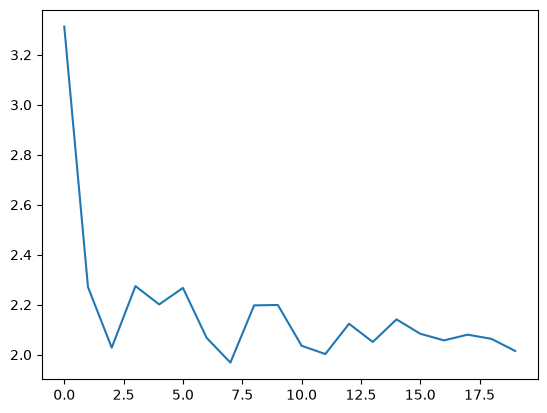

In [104]:
plt.plot(lossi)

In [106]:
# at test time, especially if we want to do inference on a single example, we do not have the batch to normalize over tho
# therefore, we compute the mean and std dev of the batch normalization over the training set once and then use it as a fixed value at test time

with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [107]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact_norm = bngain * (hpreact - bnmean) / bnstd + bnbias
    h = torch.tanh(hpreact_norm)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.034456253051758
val 2.09556245803833


In [113]:
# as we are subtracting the mean to the hidden preactivation layer, the biases for that layer are actually useless now (as they will be averaged and subtracted away)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((NUM_TOKENS, EMBEDDING_SIZE), generator=g)
W1 = torch.randn((CONTEXT_SIZE * EMBEDDING_SIZE), NUM_HIDDED_NEURONS, generator=g) * (5/3) / (CONTEXT_SIZE * EMBEDDING_SIZE)**0.5
W2 = torch.randn(NUM_HIDDED_NEURONS, NUM_TOKENS, generator=g) * 0.01
b2 = torch.randn(NUM_TOKENS, generator=g) * 0

bngain = torch.ones((1, NUM_HIDDED_NEURONS))
bnbias = torch.zeros((1, NUM_HIDDED_NEURONS))
# the batch normalization mean and std dev can also be computed during training
bnmean_running = torch.zeros((1, NUM_HIDDED_NEURONS))
bnstd_running = torch.ones((1, NUM_HIDDED_NEURONS))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(f"number of parameters: {sum([p.nelement() for p in parameters])}")

for p in parameters:
    p.requires_grad = True

number of parameters: 12097


In [ ]:

TRAINING_STEPS = 200_000
BATCH_SIZE = 32

lossi = []
for i in range(TRAINING_STEPS):
    idx = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)

    # forward
    emb = C[Xtr[idx]] # sample a random subset (of size BATCH_SIZE) of the input
    embcat = emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE)
    ## linear layer
    hpreact = embcat @ W1

    ## batch normalization layer
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact_norm = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    ## non linearity
    h = torch.tanh(hpreact_norm)
    
    ## output layer 
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[idx])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{TRAINING_STEPS:7d}: {loss.item():.4f}")
        lossi.append(loss.item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0198
 190000/ 200000: 2.1707


In [115]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    hpreact_norm = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact_norm)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056838035583496
